# rikabplotlib

Style sheets and helpers for physics figures.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from rikabplotlib import newplot, set_style, stamp, badge, legend, add_whitespace
from rikabplotlib import hist_with_errors, hist_with_outline, hist_stack, ratio_panel, function_with_band, line_with_band, plot_event
from rikabplotlib import shade, ramp, blend, gradient, hue_shift, palette, colormap, diverging_colormap
from rikabplotlib import COLORS, BLUE, GREEN, ORANGE, RED, PURPLE, DARK, GRAY

rng = np.random.default_rng(0)



In [ ]:
# Make a directory
FIGURES = Path("figures")
FIGURES.mkdir(exist_ok = True)


# Save a figure in both PDF and PNG formats
def save(fig, name):

    fig.savefig(FIGURES / ("%s.pdf" % name), bbox_inches = "tight")
    fig.savefig(FIGURES / ("%s.png" % name), bbox_inches = "tight", dpi = 150)

# Toy Data for Plotting


Mock bump hunt: mass window $m_{\gamma\gamma} \in [100, 180]$ GeV in 2 GeV bins, with three sources:

* background1, $dN/dm \propto e^{-(m - 100\,\mathrm{GeV})/28\,\mathrm{GeV}}$
* background2, a Gaussian at 150 GeV of width 30 GeV
* signal, a Gaussian at 125 GeV of width 3 GeV



In [ ]:
# the analysis window, fixed once so every histogram in the notebook shares its binning
MASS_RANGE = (100.0, 180.0)
MASS_BINS = 40

SOURCES = ["background1", "background2", "signal"]


# three sources of diphotons, returning the mass, the pt, and which source each event came from
def generate_events(n_events, rng, signal_fraction = 0.03, background2_fraction = 0.18, resonance_mass = 125.0, resonance_width = 3.0):

    n_signal = rng.binomial(n_events, signal_fraction)
    n_background2 = rng.binomial(n_events - n_signal, background2_fraction)
    n_background1 = n_events - n_signal - n_background2

    mass = np.concatenate([MASS_RANGE[0] + rng.exponential(28.0, n_background1), rng.normal(150.0, 30.0, n_background2), rng.normal(resonance_mass, resonance_width, n_signal)])
    pt = np.concatenate([rng.exponential(30.0, n_background1), rng.exponential(35.0, n_background2), rng.exponential(55.0, n_signal)])
    source = np.concatenate([np.full(n_background1, "background1"), np.full(n_background2, "background2"), np.full(n_signal, "signal")])

    # only what lands inside the window is recorded
    inside = (mass > MASS_RANGE[0]) & (mass < MASS_RANGE[1])

    return mass[inside], pt[inside], source[inside]


# charged multiplicity grows with the log of the jet pt, gluons by the color ratio
def generate_multiplicity(jet_pt, rng, n_jets = 500, color_factor = 1.0):

    return rng.poisson(color_factor * (3.0 + 2.5 * np.log(jet_pt / 20.0)), n_jets)


# a toy jet, pt falling steeply and particles crowding the axis
def generate_jet(n_particles, rng, R = 1.0):

    pts = rng.exponential(8.0, n_particles)
    radius = R * np.sqrt(rng.beta(1.2, 4.0, n_particles))
    angle = rng.uniform(0, 2 * np.pi, n_particles)

    return np.column_stack([pts, radius * np.cos(angle), radius * np.sin(angle)])


mass, pt, source = generate_events(60000, rng)
model_mass, model_pt, model_source = generate_events(600000, rng)

# the model sample is ten times the size, so every model event counts a tenth
model_weight = mass.size / model_mass.size
components = [model_mass[model_source == name] for name in SOURCES]
component_weights = [model_weight * np.ones(component.size) for component in components]

print(mass.size, "events, of which", np.sum(source == "signal"), "signal")

55101 events, of which 1852 signal


# Figures

`newplot(scale)` applies the style sheet and returns `fig, ax`. There are two modes, `scale="full"` and  `scale="column"`  Both are square. `width=` and `height=` set the size in inches directly.


`subplot_array=(rows, cols)` gives a grid.

`hist_with_errors` draws a histogram as points, with $\sigma_i = \sqrt{\sum_{k \in i} w_k^2}$
on $y$ and the half bin width on $x$. 

`stamp(x, y, line_0=, line_1=, ...)` writes lines downward from $(x, y)$ in axes coordinates,
first line bold, spaced by `delta_y`. 

`add_whitespace` scales the top of the $y$ range up to make room.

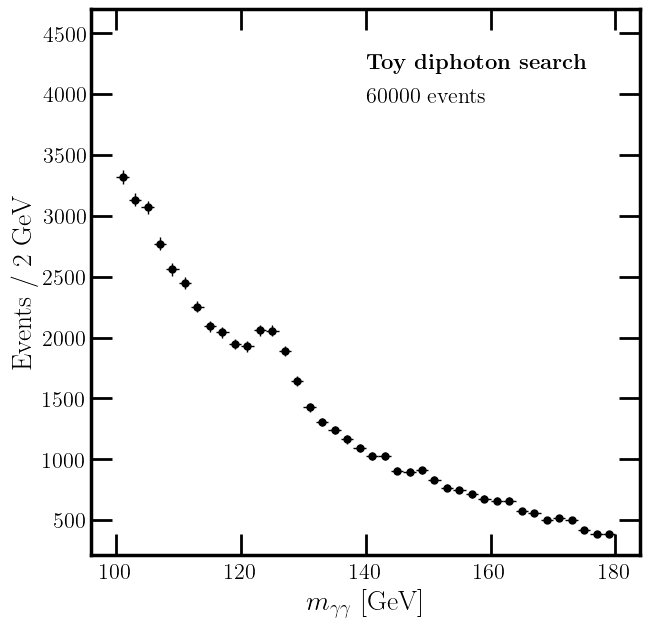

In [4]:
# make a figure at full size (8 x 8 inches by default)
fig, ax = newplot(scale = "full")

# plot the data with error bars
hist_with_errors(ax, mass, bins = MASS_BINS, range = MASS_RANGE, color = "black")

# Stamp the figure with a title and number of events, in the top left corner
stamp(0.5, 0.9, ax = ax, line_0 = "Toy diphoton search", line_1 = "60000 events")

ax.set_xlabel(r"$m_{\gamma\gamma}$ [GeV]")
ax.set_ylabel("Events / 2 GeV")
add_whitespace(ax)
plt.show()

# Sizes

`aspect_ratio` is width over height, and `golden_ratio=True` sets it to 1.618. Square is the
default and is what most figures want.

{} gives [7.08 7.08]


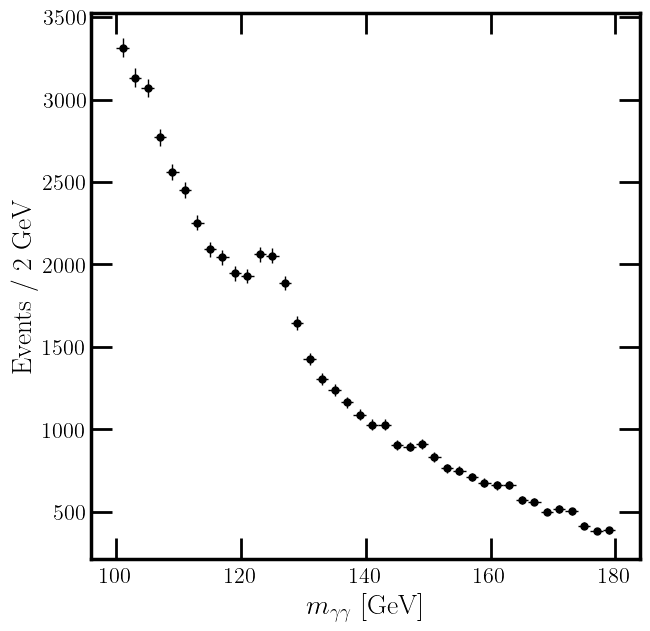

{'golden_ratio': True} gives [7.08 4.38]


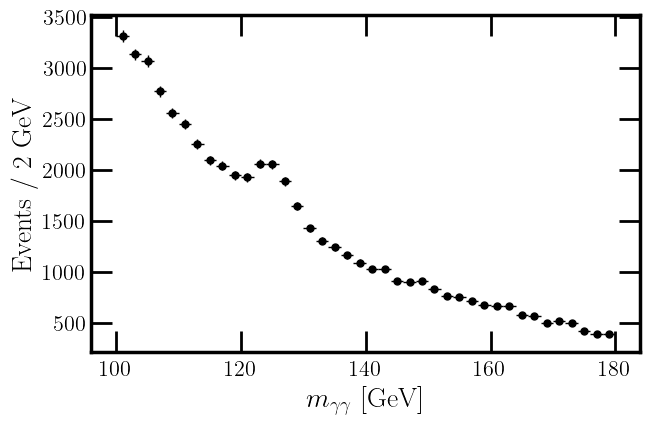

{'scale': 'column'} gives [3.4 3.4]


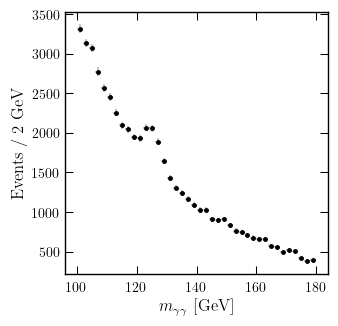

In [5]:
# the same spectrum square, wide, and at column width
for options in [{}, {"golden_ratio" : True}, {"scale" : "column"}]:

    fig, ax = newplot(**options)

    hist_with_errors(ax, mass, bins = MASS_BINS, range = MASS_RANGE, color = "black")

    ax.set_xlabel(r"$m_{\gamma\gamma}$ [GeV]")
    ax.set_ylabel("Events / 2 GeV")
    print(options, "gives", fig.get_size_inches().round(2))
    plt.show()

# No TeX

`use_tex=False` picks the sans-serif sheets and doesn't load any tex

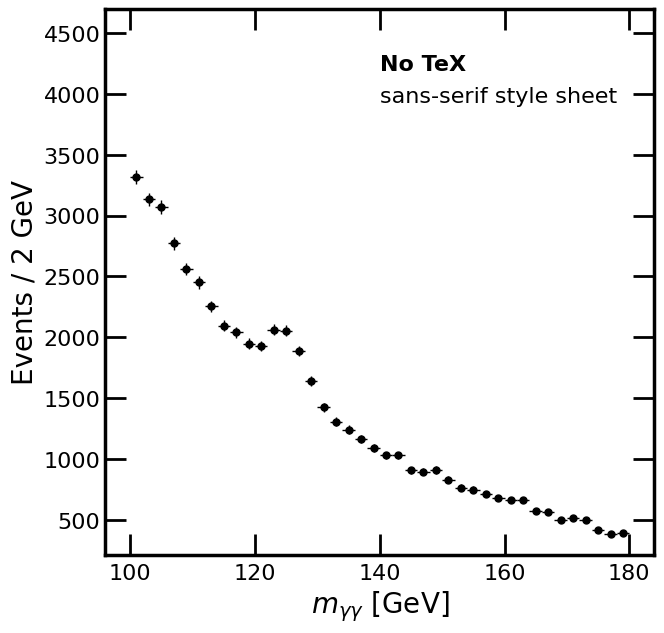

style sheet: rikab_full


In [7]:
# same figure, no latex
fig, ax = newplot(scale = "full", use_tex = False)

hist_with_errors(ax, mass, bins = MASS_BINS, range = MASS_RANGE, color = "black")
stamp(0.5, 0.9, ax = ax, line_0 = "No TeX", line_1 = "sans-serif style sheet")

ax.set_xlabel(r"$m_{\gamma\gamma}$ [GeV]")
ax.set_ylabel("Events / 2 GeV")
add_whitespace(ax)
plt.show()

# back to the TeX style for the rest of the notebook
print("style sheet:", set_style("full", use_tex = True))

# Stacks

`hist_stack(ax, components, ...)` draws the components stacked

`legend` draws the key with both the fill and outline properly

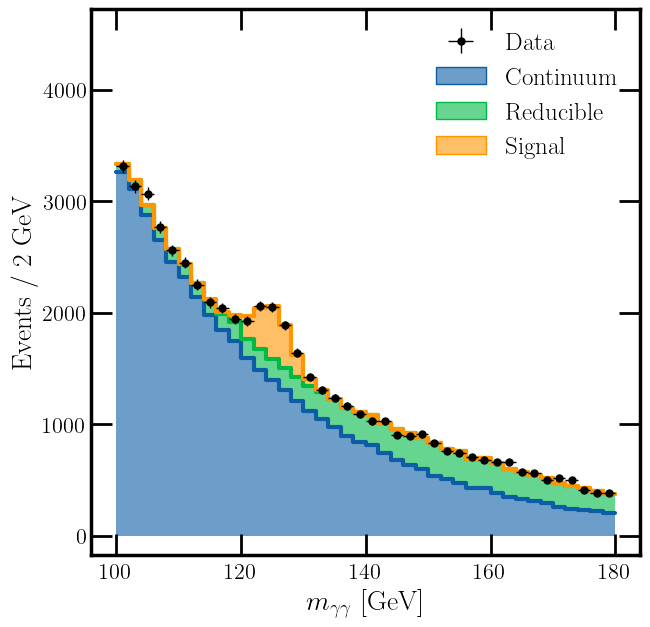

In [ ]:
# three components stacked under the data, signal on top where it can be seen
fig, ax = newplot()

model = hist_stack(ax, components, bins = MASS_BINS, range = MASS_RANGE, weights = component_weights, colors = [BLUE, GREEN, ORANGE], labels = ["Background1", "Background2", "Signal"])
data = hist_with_errors(ax, mass, bins = MASS_BINS, range = MASS_RANGE, color = "black", label = "Data")

ax.set_xlabel(r"$m_{\gamma\gamma}$ [GeV]")
ax.set_ylabel("Events / 2 GeV")
add_whitespace(ax)
legend(ax)

save(fig, "stack")
plt.show()

# Ratios and pulls

`newplot(ratio=True)` returns `fig, main, pull`, a body over a short panel sharing $x$. Pass
`ratio=(4, 1)` for other height ratios, `square=True` to box the pair into a square, and
`subplot_array=(1, n)` for $n$ such columns.

`ratio_panel(ax, x, numerator, denominator, numerator_errors, denominator_errors, mode)`
fills the lower panel, given counts $n_i$ and model $m_i$:

* `"ratio"`: $n_i / m_i$, against 1
* `"difference"`: $n_i - m_i$, against 0
* `"pull"`: $(n_i - m_i)/\sqrt{\sigma_{n,i}^2 + \sigma_{m,i}^2}$, against 0

Can omit `denominator_errors` if desired

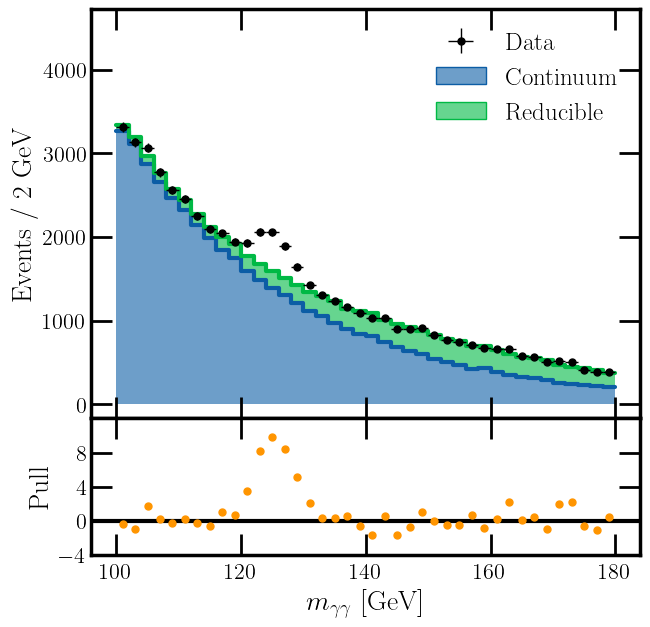

largest pull: 9.9 at 125.0 GeV


In [ ]:
# background events
background = [model_mass[model_source == name] for name in ["background1", "background2"]]


# sideband region 
def in_sidebands(m):

    return (m < 115.0) | (m > 140.0)


background_weight = np.sum(in_sidebands(mass)) / np.sum(in_sidebands(np.concatenate(background)))
background_weights = [background_weight * np.ones(component.size) for component in background]

# ratio plot figure
fig, main, pull = newplot(ratio = True)

# Plot histograms on the main panel
model = hist_stack(main, background, bins = MASS_BINS, range = MASS_RANGE, weights = background_weights, colors = [BLUE, GREEN], labels = ["Background1", "Background2"])
data = hist_with_errors(main, mass, bins = MASS_BINS, range = MASS_RANGE, color = "black", label = "Data")

# Plot the ratio in "pull" mode (difference / uncertainty)
pulls = ratio_panel(pull, data.centers, data.counts, model.counts, data.errors, model.errors, mode = "pull", color = ORANGE)



main.set_ylabel("Events / 2 GeV")
pull.set_xlabel(r"$m_{\gamma\gamma}$ [GeV]")
pull.set_ylabel("Pull")
pull.set_ylim(-4, 12)

add_whitespace(main)
legend(main)

save(fig, "spectrum_pull")
plt.show()

print("largest pull:", round(np.nanmax(pulls.values), 1), "at", data.centers[np.nanargmax(pulls.values)], "GeV")

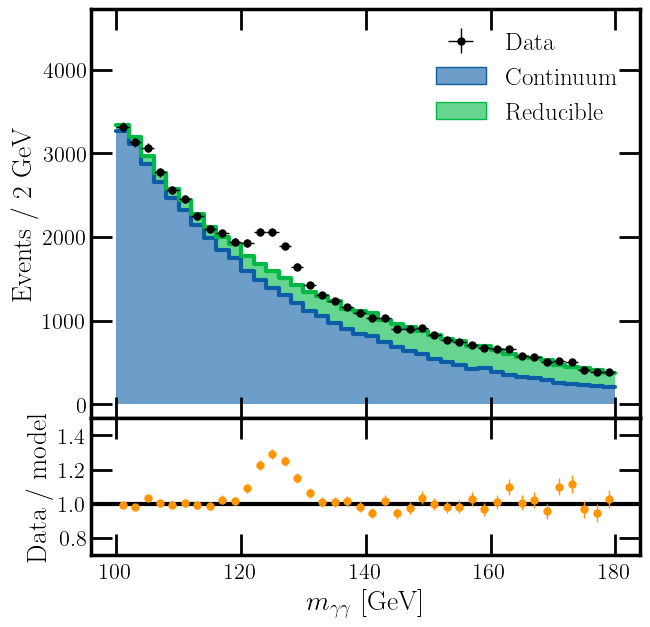

bins with no defined ratio: 0


In [ ]:
# Same thing but with the ratio instead of the pull
fig, main, pull = newplot(ratio = True)

model = hist_stack(main, background, bins = MASS_BINS, range = MASS_RANGE, weights = background_weights, colors = [BLUE, GREEN], labels = ["Background1", "Background2"])
data = hist_with_errors(main, mass, bins = MASS_BINS, range = MASS_RANGE, color = "black", label = "Data")

# Change "pull" to "ratio" 
ratios = ratio_panel(pull, data.centers, data.counts, model.counts, data.errors, model.errors, mode = "ratio", color = ORANGE)

main.set_ylabel("Events / 2 GeV")
pull.set_xlabel(r"$m_{\gamma\gamma}$ [GeV]")
pull.set_ylabel("Data / model")
pull.set_ylim(0.7, 1.5)
add_whitespace(main)
legend(main)
plt.show()

print("bins with no defined ratio:", ratios.dropped)

# Outlines

`hist_with_outline`: a fill at `alpha_1` under an outline at
`alpha_2`

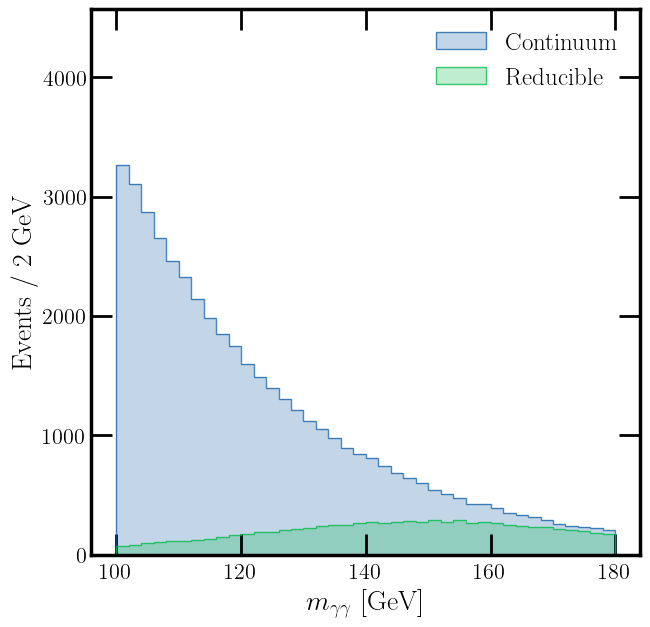

In [ ]:
# the two backgrounds shown separately rather than piled up
fig, ax = newplot()

hist_with_outline(ax, background[0], bins = MASS_BINS, range = MASS_RANGE, weights = background_weights[0], color = BLUE, label = "Background1")
hist_with_outline(ax, background[1], bins = MASS_BINS, range = MASS_RANGE, weights = background_weights[1], color = GREEN, label = "Background2")

ax.set_xlabel(r"$m_{\gamma\gamma}$ [GeV]")
ax.set_ylabel("Events / 2 GeV")
add_whitespace(ax)
legend(ax)
plt.show()

# Fits

`function_with_band(ax, f, range, params, pcov)` given a function $f$ and a $pcov$, plots $f(x; \hat p)$ and fills the band from
1000 draws $p \sim \mathcal{N}(\hat p, \Sigma)$



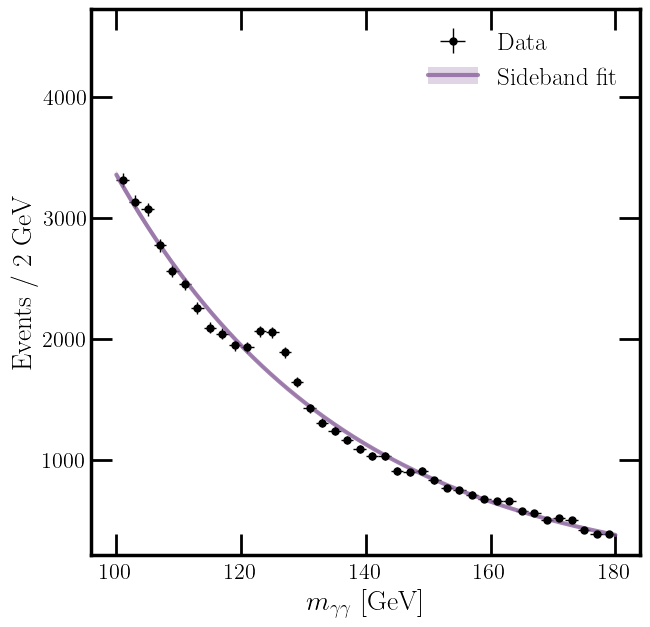

falloff length: 36.7 GeV


In [15]:
# Function to fit (example)
def falling(m, slope, log_norm):

    return np.exp(slope * m + log_norm)

# Plot the histogram
fig, ax = newplot()
data = hist_with_errors(ax, mass, bins = MASS_BINS, range = MASS_RANGE, color = "black", label = "Data")

# Fit the sidebands 
sideband = (data.counts > 0) & ((data.centers < 115.0) | (data.centers > 140.0))
params, pcov = np.polyfit(data.centers[sideband], np.log(data.counts[sideband]), 1, w = np.sqrt(data.counts[sideband]), cov = True)

# Plot our fit with a band showing the uncertainty
function_with_band(ax, falling, MASS_RANGE, params = params, pcov = pcov, color = PURPLE, label = "Sideband fit", rng = rng)

ax.set_xlabel(r"$m_{\gamma\gamma}$ [GeV]")
ax.set_ylabel("Events / 2 GeV")
add_whitespace(ax)
legend(ax)
plt.show()

print("falloff length:", round(-1 / params[0], 1), "GeV")

# Bands over samples

`line_with_band(ax, x, samples, mode)` takes one sample array per $x$. `"median"` draws the
median with the 25 to 75 percent band, `"mean"` the mean with $\pm\sigma$. 

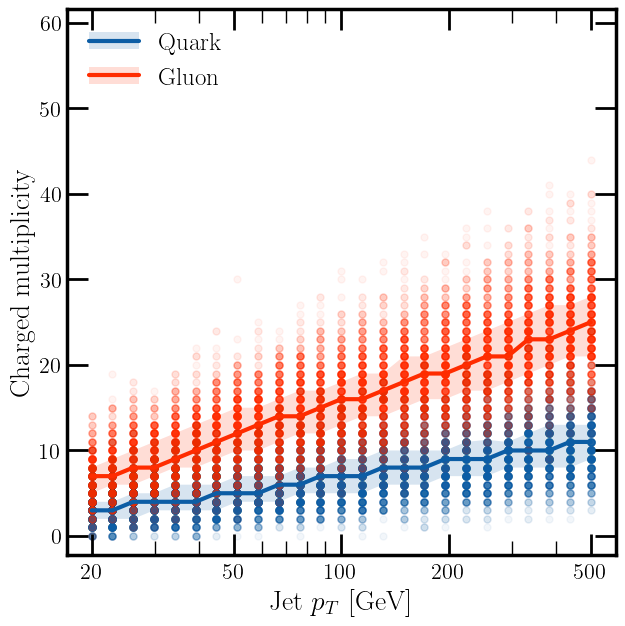

In [ ]:
# log-spaced pt bins, 500 jets thrown in each
jet_pt = np.geomspace(20.0, 500.0, 25)

quark = [generate_multiplicity(p, rng, color_factor = 1.0) for p in jet_pt]
gluon = [generate_multiplicity(p, rng, color_factor = 9 / 4) for p in jet_pt]

fig, ax = newplot()


# Plot the individual poiints
for i, p in enumerate(jet_pt):
    plt.scatter([p] * 500, quark[i], color = BLUE, alpha = 0.05)
    plt.scatter([p] * 500, gluon[i], color = RED, alpha = 0.05)


# Plot the bands of the mean(median) and std(IQR)
line_with_band(ax, jet_pt, quark, mode = "median", color = BLUE, label = "Quark")
line_with_band(ax, jet_pt, gluon, mode = "median", color = RED, label = "Gluon")




ax.set_xscale("log")
ax.set_xticks([20, 50, 100, 200, 500])
ax.set_xticklabels(["20", "50", "100", "200", "500"])
ax.set_xlabel(r"Jet $p_T$ [GeV]")
ax.set_ylabel("Charged multiplicity")
add_whitespace(ax)
legend(ax, loc = "upper left")

save(fig, "multiplicity")
plt.show()

# Event displays

`plot_event(ax, event, R)` takes rows of $(p_T, y, \phi)$ and puts them in the
rapidity-azimuth plane, with marker area $\propto p_T / \sum p_T$. 

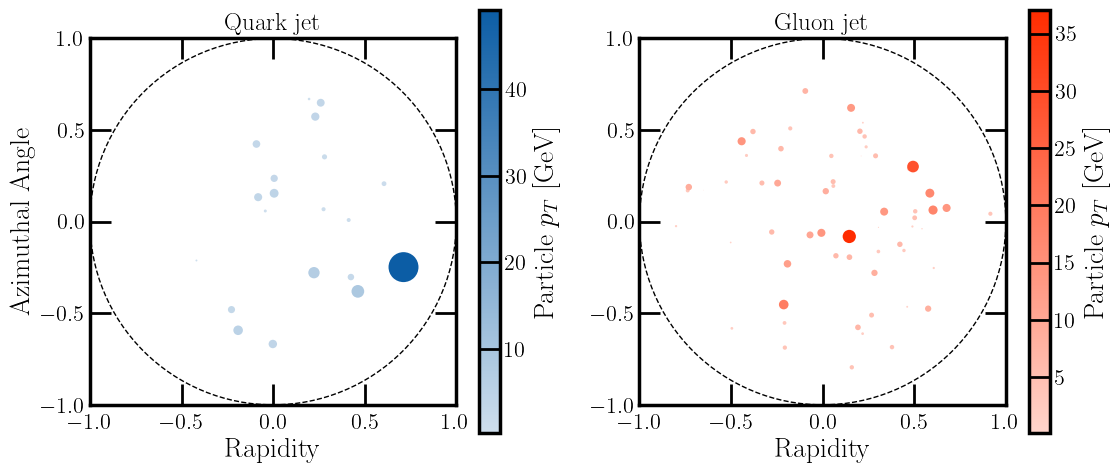

In [ ]:
# create two plots
fig, axes = newplot(subplot_array = (1, 2), width = 13, height = 5.5)

# two jets to plot
quark_jet = generate_jet(20, rng)
gluon_jet = generate_jet(60, rng)

# Plot the jets
plot_event(axes[0], quark_jet, R = 1.0, values = quark_jet[:, 0], cmap = colormap(BLUE, start = 0.8), colorbar = r"Particle $p_T$ [GeV]", title = "Quark jet", label = None)
plot_event(axes[1], gluon_jet, R = 1.0, values = gluon_jet[:, 0], cmap = colormap(RED, start = 0.8), colorbar = r"Particle $p_T$ [GeV]", title = "Gluon jet", label = None)

# both panels share the axis, so the right one does not repeat the label
axes[1].set_ylabel("")

save(fig, "jets")
plt.show()

# Colors

`COLORS`, `BLUE` through `GRAY`, and `palette(n)` give the style cycle by name. These are my own palletes, any matplotlib color will work however.

`shade(c, f)` and `ramp(c, n)` move the lightness at fixed hue. 

`blend(a, b, f)` interpolates
in HSV and takes the shorter arc in hue, so blue to red passes through magenta;
`space="rgb"` interpolates the channels instead and desaturates through the middle. 

`gradient`
is `blend` at $n$ points, and `hue_shift` rotates the hue by $\delta$ turns.

`colormap(c)` is the continuous `ramp`. `diverging_colormap(low, high)` runs low through white
to high, which is what a signed quantity like a pull needs.

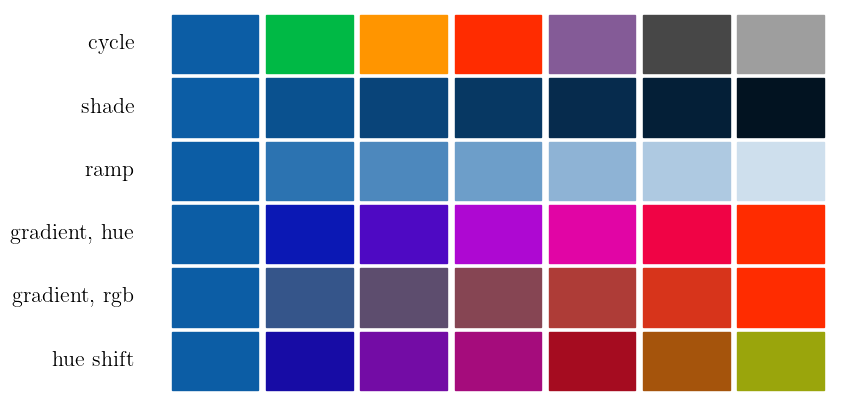

In [20]:
# one row of swatches per construction
def draw_swatches(ax, rows):

    for row, (name, colors) in enumerate(rows):

        for column, color in enumerate(colors):
            ax.add_patch(plt.Rectangle((column, -row), 0.92, 0.92, color = color))

        ax.text(-0.4, -row + 0.46, name, horizontalalignment = "right", verticalalignment = "center")

    ax.set_xlim(-0.4, max(len(colors) for name, colors in rows))
    ax.set_ylim(-len(rows) + 0.92, 1.0)
    ax.axis("off")


rows = [("cycle", palette(7)),
        ("shade", [shade(BLUE, f) for f in np.linspace(0, 0.8, 7)]),
        ("ramp", ramp(BLUE, 7, toward = "white", stop = 0.8)),
        ("gradient, hue", gradient(BLUE, RED, 7)),
        ("gradient, rgb", gradient(BLUE, RED, 7, space = "rgb")),
        ("hue shift", [hue_shift(BLUE, d) for d in np.linspace(0, 0.6, 7)])]

fig, ax = newplot(width = 9, height = 5)
draw_swatches(ax, rows)

save(fig, "colors")
plt.show()

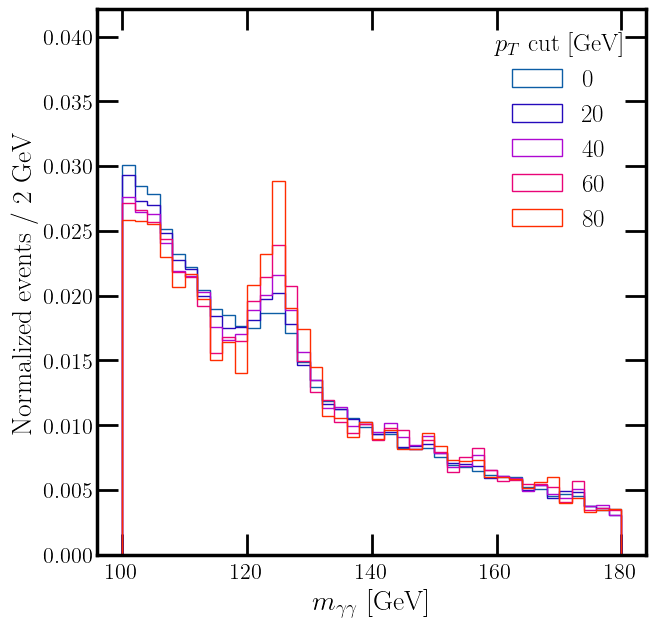

In [21]:
# a harder pt cut leaves more of the resonance behind, one color per cut
cuts = [0.0, 20.0, 40.0, 60.0, 80.0]

fig, ax = newplot()

for cut, color in zip(cuts, gradient(BLUE, RED, len(cuts))):

    ax.hist(mass[pt > cut], bins = MASS_BINS, range = MASS_RANGE, histtype = "step", density = True, color = color, label = "%d" % cut)

ax.set_xlabel(r"$m_{\gamma\gamma}$ [GeV]")
ax.set_ylabel("Normalized events / 2 GeV")
add_whitespace(ax)
legend(ax, title = r"$p_T$ cut [GeV]")

save(fig, "cuts")
plt.show()

# Full figure

 `badge` and `stamp`.

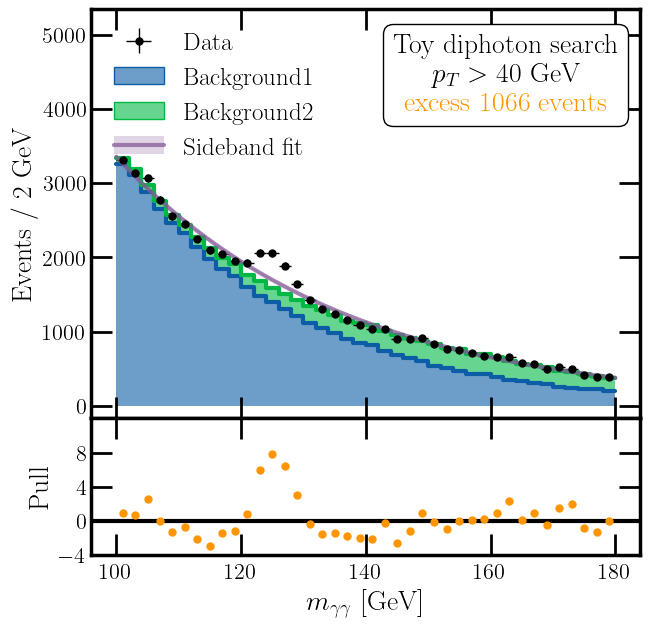

excess of 1066 events over the fitted background within 6 GeV of the peak


In [29]:
# Selection to mock a bump hunt
selected = mass[pt > 0.0]

# Make a figure with a ratio panel
fig, main, pull = newplot(ratio = True)

# Plot the data
data = hist_with_errors(main, selected, bins = MASS_BINS, range = MASS_RANGE, color = "black", label = "Data")


model = hist_stack(main, background, bins = MASS_BINS, range = MASS_RANGE, weights = background_weights, colors = [BLUE, GREEN], labels = ["Background1", "Background2"])

# blind the signal region, fit the rest, extrapolate across the whole window
sideband = (data.counts > 0) & ((data.centers < 115.0) | (data.centers > 140.0))
params, pcov = np.polyfit(data.centers[sideband], np.log(data.counts[sideband]), 1, w = np.sqrt(data.counts[sideband]), cov = True)
function_with_band(main, falling, MASS_RANGE, params = params, pcov = pcov, color = PURPLE, label = "Sideband fit", rng = rng)

# the fit evaluated in each bin is the model the data is pulled against
model = falling(data.centers, *params)
pulls = ratio_panel(pull, data.centers, data.counts, model, data.errors, mode = "pull", color = ORANGE)

peak = np.abs(data.centers - 125.0) < 6.0
excess = int(np.sum(data.counts[peak] - model[peak]))


# BADGE: a fancy label
badge(main, ["Toy diphoton search", r"$p_T > 40$ GeV", "excess %d events" % excess], xy = (0.96, 0.94), loc = (1, 1), colors = ["black", "black", ORANGE], weights = ["bold", "normal", "bold"])

main.set_ylabel("Events / 2 GeV")
pull.set_xlabel(r"$m_{\gamma\gamma}$ [GeV]")
pull.set_ylabel("Pull")
pull.set_ylim(-4, 12)
add_whitespace(main, upper_fraction = 1.5)
legend(main, loc = "upper left")

save(fig, "spectrum_fit")
plt.show()

print("excess of", excess, "events over the fitted background within 6 GeV of the peak")